# UN General Debate speeches, conflict and military spending

This notebook builds one country-year dataset from three sources: UN General Debate speeches, the UCDP/PRIO Armed Conflict Dataset (v26.1) and SIPRI military expenditure. It then answers our exploratory question: do trust/cooperation rhetoric, military-threat rhetoric and military spending in year t differ depending on whether a country is in conflict in year t+1? The scope is 1990 to 2025, and the unit is one speech.

## Setup

Create a `.env` file in the project folder with four paths: `data_path` (folder with the speech `.txt` files, from Canvas), `speech_path` (`Speakers_by_session.xlsx`), `conflicts_path` (UCDP CSV) and `sipri_path` (SIPRI Excel file). The UCDP and SIPRI files can be downloaded <a href='https://drive.google.com/drive/folders/1Ach27hl0Fv4v5MpKTQG63gh2urtSwI1h?usp=sharing'>here</a>. The cell below loads the paths and stops if one is missing.

In [1]:
import os
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib.ticker import PercentFormatter
from nltk.corpus import stopwords
from scipy import stats

load_dotenv(override=True)

DATA_PATH = os.getenv("data_path")
SPEECH_PATH = os.getenv("speech_path") or os.getenv("speach_path")
CONFLICTS_PATH = os.getenv("conflicts_path")
SIPRI_PATH = os.getenv("sipri_path")

required_paths = {
    "data_path": DATA_PATH,
    "speech_path": SPEECH_PATH,
    "conflicts_path": CONFLICTS_PATH,
    "sipri_path": SIPRI_PATH,
}
missing_paths = [name for name, value in required_paths.items() if not value]
if missing_paths:
    raise ValueError(
        f"Missing environment variables: {', '.join(missing_paths)}"
    )

# All figures are saved here as PDF so the report can include them
FIGURES_PATH = "figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

# The zero-shot scoring takes over an hour. Keep this False to load the saved scores instead.
RUN_SCORING = False
SCORES_PATH = "merged_data.csv"

## Dataset I: UN General Debate speeches

We load the speech metadata (one row per speech) and drop an empty column.

In [2]:
excel = pd.read_excel(SPEECH_PATH)
# lets drop unnecessary column
speach_df = excel.drop(columns=["Unnamed: 6"])

Each speech is a `.txt` file named `ISO_session_year.txt`. We match every file to its metadata row on ISO code, session and year. Session and year are compared as integers, because the file names are zero-padded ("05" vs 5).

In [3]:
# Make the Excel values use the same types as the values in the filenames.
speach_df["ISO Code"] = speach_df["ISO Code"].astype(str).str.strip()
speach_df["Session"] = pd.to_numeric(speach_df["Session"])
speach_df["Year"] = pd.to_numeric(speach_df["Year"])

if "Speech" not in speach_df.columns:
    speach_df["Speech"] = pd.NA

number_of_sessions = 0
files_processed = 0
files_matched = 0
files_unmatched = 0
files_skipped = 0
skipped_files = []
unmatched_files = []

for folder_name in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for session_name in os.listdir(folder_path):
        session_path = os.path.join(folder_path, session_name)
        if not os.path.isdir(session_path):
            continue

        number_of_sessions += 1

        for txt_file in os.listdir(session_path):
            if not txt_file.endswith(".txt"):
                continue

            parts = txt_file[:-4].split("_")
            if len(parts) != 3:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            iso_code, session_num, year = parts
            try:
                session_num = int(session_num)
                year = int(year)
            except ValueError:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            try:
                with open(os.path.join(session_path, txt_file), "r", encoding="utf-8") as file:
                    speech_text = file.read()
            except (OSError, UnicodeDecodeError):
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            files_processed += 1
            mask = (
                (speach_df["ISO Code"] == iso_code.strip())
                & (speach_df["Session"] == session_num)
                & (speach_df["Year"] == year)
            )

            if not mask.any():
                files_unmatched += 1
                unmatched_files.append(txt_file)
                continue

            # Update every row when the metadata contains duplicate keys.
            speach_df.loc[mask, "Speech"] = speech_text
            files_matched += 1

missing_speeches = speach_df["Speech"].isna().sum()
print(f"Sessions found: {number_of_sessions}")
print(f"Speech files processed: {files_processed}")
print(f"Speech files matched: {files_matched}")
print(f"Speech files without a metadata match: {files_unmatched}")
print(f"Files skipped: {files_skipped} {skipped_files}")
print(f"Metadata rows without speech: {missing_speeches}")

Sessions found: 80
Speech files processed: 11141
Speech files matched: 11063
Speech files without a metadata match: 78
Files skipped: 1 ['.DS_Store-to-UTF-8.txt']
Metadata rows without speech: 54


Only 54 metadata rows have no speech file, so we drop them. Missing values in `Post` become "Unknown".

In [4]:
speach_df = speach_df.dropna(subset=["Speech"])
speach_df["Post"] = speach_df["Post"].fillna("Unknown")
print(f"Speeches: {len(speach_df)}")

Speeches: 11080


### Cleaning country names

The three datasets spell the same country differently (extra spaces, typos, formal names and old names). We strip whitespace and fix one corrupted cell where a broken Excel formula ended up in `Country`. Then we apply a hand-built dictionary of true one-to-one renames to SIPRI-style names.

In [5]:
speach_df["Country"] = speach_df["Country"].str.strip()

# Fix one corrupted cell (broken Excel formula leaked into 'Country')
speach_df.loc[speach_df["Country"] == "29+C70+A7+D71:E74", "Country"] = "Ethiopia"

In [6]:
# True 1-to-1 renames: same country/entity, just an old name -> current SIPRI-style name
rename_dict = {
    "Burma": "Myanmar",
    "Union of Burma": "Myanmar",
    "Union of Myanmar": "Myanmar",
    "Myanmar / Burma": "Myanmar",
    "Ceylon": "Sri Lanka",
    "Ceylon (Sri Lanka)": "Sri Lanka",
    "Zaire": "Congo, DR",
    "Congo, Leopoldville": "Congo, DR",
    "Congo, the Democratic Republic of the/Zaire": "Congo, DR",
    "Democratic Republic of Congo": "Congo, DR",
    "Democratic Republic Of Congo": "Congo, DR",
    "Democratic Republic of the Congo": "Congo, DR",
    "DRC": "Congo, DR",
    "Congo, Brazzaville": "Congo, Republic",
    "Congo (Brazzaville": "Congo, Republic",
    "Congo, the Peoples Republic of the": "Congo, Republic",
    "Dahomey": "Benin",
    "Benin (Dahomey)": "Benin",
    "Upper Volta": "Burkina Faso",
    "Upper Volta/Burkina Faso": "Burkina Faso",
    "Siam": "Thailand",
    "Swaziland": "Eswatini",
    "Kingdom of Eswatini": "Eswatini",
    "Macedonia": "North Macedonia",
    "Macedonia, the former Yugoslav Republic of": "North Macedonia",
    "Republic of North Macedonia": "North Macedonia",
    "Kampuchea": "Cambodia",
    "Democratic Kampuchea": "Cambodia",
    "Khmer Republic": "Cambodia",
    "Cambodia /Kampuchea": "Cambodia",
    "Western Samoa": "Samoa",
    "Independent State of Samoa": "Samoa",
    "Samoa": "Samoa",
    "Timor-Leste": "Timor Leste",
    "Democratic Republic of Timor-Leste": "Timor Leste",
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "Republic of Turkey": "Türkiye",
}

In [7]:
speach_df["Country"] = speach_df["Country"].replace(rename_dict)
print(f"Distinct country names after renaming: {speach_df['Country'].nunique()}")

Distinct country names after renaming: 514


### Historical entities

The USSR, Czechoslovakia, Yugoslavia, divided Germany and divided Yemen no longer exist as single countries. Mapping them to one modern successor would be wrong, so we flag them in `historical_entity_unmatched` instead of renaming them. They stay usable for text analysis but are dropped when we restrict to the study scope.

In [8]:
impossible_bucket = [
    # USSR variants
    "USSR", "USSR ", "Union of Socialist Soviet Republics",
    "Union of Sovier Socialist Republics", "Union of Soviet Socialist Republics",
    "Russian Federation (USSR)",

    # Czechoslovakia
    "Czechoslovakia", "Czechoslovak Socialist Republic",

    # Yugoslavia
    "Yugoslavia", "Serbia and Montenegro",

    # Germany (pre-unification, both sides)
    "German Democratic Republic", "Germany Democratic Republic",
    "Democratic Republic of Germany", "GDR", "DDR", "FDR", "FDR (Germany)",
    "Federal Republic Germany", "Federal Republic of Germany",
    "Republica Federal Alemana",

    # Yemen (pre-1990 unification, both sides)
    "Yemen Arab Republic",

    # Byelorussian/Ukrainian SSR (distinct UN seats pre-1991, now part of modern Belarus/Ukraine
    # via full independence, not a simple rename - USSR breakup case)
    "BSSR", "BelSSR", "Byelorussian Soviet Socialist Republic",
    "Byelorussian Soviet Socialist Repulic",
    "Belarus, Byelorussian Soviet Socialist Republic",
    "UkrSSR", "Ukraine SSR", "Ukrainian Soviet Socialist Republic",
    "Ukranian SSR", "Ukranian Soviet Socialist Republic",
]
# Flag these rows explicitly instead of dropping them
speach_df["historical_entity_unmatched"] = speach_df["Country"].isin(impossible_bucket)

"Federal Republic of Germany" is ambiguous: before 1990 it means West Germany, from 1990 on it is the official name of unified Germany. From 1990 on we therefore rename it to Germany and remove the flag.

In [9]:
mask_germany_post1990 = (
    (speach_df["Country"] == "Federal Republic of Germany")
    & (speach_df["Year"] >= 1990)
)
speach_df.loc[mask_germany_post1990, "Country"] = "Germany"
speach_df.loc[mask_germany_post1990, "historical_entity_unmatched"] = False

n_flagged = speach_df["historical_entity_unmatched"].sum()
print(f"Rows flagged as historical/unmatched: {n_flagged} of {len(speach_df)} ({n_flagged / len(speach_df):.1%})")

Rows flagged as historical/unmatched: 248 of 11080 (2.2%)


Result: 248 of 11,080 speeches (2.2%) are flagged as historical entities. Almost all are from before 1990; the few inside our window are the USSR, Czechoslovakia and Yugoslavia (1990 to 1993) and Yugoslavia / Serbia and Montenegro (2001 to 2005).

## Dataset II: UCDP/PRIO armed conflicts

In UCDP, one row is one conflict in one year. The `location` field can name several countries separated by ", ", so we split it into one row per country.

In [10]:
conflicts_df = pd.read_csv(CONFLICTS_PATH)

# Split multi-country location entries into separate rows.
conflicts_df = conflicts_df.assign(
    Country=conflicts_df["location"].str.split(", ")
).explode("Country")

conflicts_df["Country"] = conflicts_df["Country"].str.strip()

We apply the same renames and historical flags as for the speeches, plus a few UCDP-specific names. In UCDP, bare "Congo" is the Republic of Congo and "DR Congo (Zaire)" is the DRC.

In [11]:
# UCDP-specific renames: same entities as before, but UCDP phrases them differently.
ucdp_rename_dict = {
    "Cambodia (Kampuchea)": "Cambodia",
    "Myanmar (Burma)": "Myanmar",
    "Madagascar (Malagasy)": "Madagascar",
    "DR Congo (Zaire)": "Congo, DR",
    "Congo": "Congo, Republic",
}

rename_dict.update(ucdp_rename_dict)

ucdp_impossible_bucket = [
    "Russia (Soviet Union)",
    "South Yemen",
    "Yemen (North Yemen)",
    "Serbia (Yugoslavia)",
    "South Vietnam",
    "Vietnam (North Vietnam)",
    "Zimbabwe (Rhodesia)",
]

impossible_bucket.extend(ucdp_impossible_bucket)

conflicts_df["Country"] = conflicts_df["Country"].replace(rename_dict)
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

Some UCDP labels keep an old name for the whole history of a conflict. We correct the rows after the state changed: Russia from 1992, Viet Nam from 1976 and Yemen from 1990.

In [12]:
# Russia (Soviet Union): USSR dissolved in 1991. Post-1991 rows are modern Russia.
mask_russia_post1991 = (
    (conflicts_df["Country"] == "Russia (Soviet Union)")
    & (conflicts_df["year"] >= 1992)
)
conflicts_df.loc[mask_russia_post1991, "Country"] = "Russia"
conflicts_df.loc[mask_russia_post1991, "historical_entity_unmatched"] = False

# Vietnam (North Vietnam): unified with South Vietnam in 1976. Post-1976 rows are unified Vietnam.
mask_vietnam_post1976 = (
    (conflicts_df["Country"] == "Vietnam (North Vietnam)")
    & (conflicts_df["year"] >= 1976)
)
conflicts_df.loc[mask_vietnam_post1976, "Country"] = "Viet Nam"
conflicts_df.loc[mask_vietnam_post1976, "historical_entity_unmatched"] = False

# Yemen (North Yemen): unified with South Yemen in 1990. Post-1990 rows are unified Yemen.
mask_yemen_post1990 = (
    (conflicts_df["Country"] == "Yemen (North Yemen)")
    & (conflicts_df["year"] >= 1990)
)
conflicts_df.loc[mask_yemen_post1990, "Country"] = "Yemen"
conflicts_df.loc[mask_yemen_post1990, "historical_entity_unmatched"] = False

Last renames to SIPRI style. Hyderabad, a princely state absorbed by India in 1948, is flagged as historical.

In [13]:
final_rename_dict = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Gambia": "Gambia, The",
    "Ivory Coast": "Cote d'Ivoire",
    "Kyrgyzstan": "Kyrgyz Republic",
    "South Korea": "Korea, South",
}
rename_dict.update(final_rename_dict)
conflicts_df["Country"] = conflicts_df["Country"].replace(final_rename_dict)

impossible_bucket.append("Hyderabad")
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

We aggregate UCDP to one row per country-year, leaving out historical rows. For each country-year we keep whether any conflict was active, the highest intensity (1 = minor, 2 = war), the number of distinct conflicts, and whether any conflict reached war level.

In [14]:
def has_war(intensity_levels):
    """True if any conflict in the group reached war level (intensity 2)."""
    return (intensity_levels == 2).any()


conflicts_agg = (
    conflicts_df[~conflicts_df["historical_entity_unmatched"]]  # drop historical/unmatched entities first
    .groupby(["Country", "year"])
    .agg(
        conflict_active=("conflict_id", "count"),       # will convert to 1/0 below
        max_intensity=("intensity_level", "max"),        # 1=Minor, 2=War
        n_conflicts=("conflict_id", "nunique"),           # number of distinct conflicts that year
        any_war=("intensity_level", has_war),            # True if any conflict reached War level
    )
    .reset_index()
)

# conflict_active should be a 1/0 flag, not a raw count
conflicts_agg["conflict_active"] = (conflicts_agg["conflict_active"] > 0).astype(int)
conflicts_agg["any_war"] = conflicts_agg["any_war"].astype(int)

conflicts_agg = conflicts_agg.rename(columns={"year": "Year"})

print(f"UCDP rows after splitting locations: {len(conflicts_df)}")
print(f"Of these flagged as historical: {conflicts_df['historical_entity_unmatched'].sum()}")
print(f"Country-years after aggregation: {len(conflicts_agg)}")

UCDP rows after splitting locations: 2990
Of these flagged as historical: 101
Country-years after aggregation: 2024


## Dataset III: SIPRI military spending

We use the sheet "Share of GDP". Rows where every year is empty are region headers (such as "Africa") and are dropped, and codes like ".." and "xxx" are read as missing.

In [15]:
def load_sipri_sheet(path, sheet_name, header_row, year_start_col):
    df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=header_row,              # row 6 (0-indexed: 5)
        na_values=["..", "xxx", "..."]  # treat these as missing
    )

    # Identify the year columns (everything from year_start_col onward).
    # Doing this BEFORE dropping 'Notes' keeps the column positions predictable.
    year_cols = df.columns[year_start_col:]

    # Drop region header rows (e.g. "Africa") and blank spacer rows: their year
    # columns are all empty, even though 'Country' itself is filled in.
    df = df.dropna(subset=year_cols, how="all")

    df = df.drop(columns="Notes")
    return df


# year_start_col=2 because the raw columns are: [Country, Notes, 1949, 1950, ...]
gdp_share = load_sipri_sheet(SIPRI_PATH, "Share of GDP", header_row=5, year_start_col=2)

SIPRI is wide (one column per year), so we melt it into long format with one row per (Country, Year). Missing spending stays missing and is never filled with 0, because 0 would claim that a country spent nothing. Values are a fraction of GDP (0.02 means 2%). North Korea, Comoros, Grenada and Suriname have no SIPRI data at all; this is a real gap, not a naming problem.

In [16]:
gdp_long = gdp_share.melt(
    id_vars=["Country"],
    var_name="Year",
    value_name="milex_pct_gdp"
)

gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long = gdp_long.dropna(subset=["milex_pct_gdp"])

## Merging the three datasets

### One country name per ISO code

In 2019 and 2020 especially, many speeches use formal names such as "Kingdom of Morocco" that do not exist in SIPRI or UCDP, so without a fix they would silently get no conflict and no spending. The ISO code is reliable, so for each ISO code we pick one name: the most common name that also appears in SIPRI or UCDP, otherwise simply the most common name. The mapping is built from in-scope speeches (1990 to 2025, not flagged) and then applied to all speeches.

In [17]:
reference_names = set(gdp_long["Country"]) | set(conflicts_agg["Country"])


def pick_canonical_name(names):
    """Most common name that also exists in SIPRI or UCDP, otherwise the most common name."""
    counts = names.value_counts()
    for name in counts.index:
        if name in reference_names:
            return name
    return counts.index[0]


in_scope = speach_df[
    (speach_df["Year"] >= 1990)
    & (speach_df["Year"] <= 2025)
    & (~speach_df["historical_entity_unmatched"])
]

iso_to_name = {}
for iso_code, names in in_scope.groupby("ISO Code")["Country"]:
    iso_to_name[iso_code] = pick_canonical_name(names)

has_mapping = speach_df["ISO Code"].isin(iso_to_name.keys())
new_names = speach_df.loc[has_mapping, "ISO Code"].map(iso_to_name)
n_renamed = (speach_df.loc[has_mapping, "Country"] != new_names).sum()
speach_df.loc[has_mapping, "Country"] = new_names

print(f"ISO codes in scope: {len(iso_to_name)}")
print(f"Speeches whose country name changed: {n_renamed}")

ISO codes in scope: 196
Speeches whose country name changed: 982


We left-join UCDP and SIPRI onto the speeches on (Country, Year). No UCDP row means no conflict, so missing conflict columns become 0, while missing spending stays NaN. Then we keep 1990 to 2025 and drop the flagged historical rows.

In [18]:
# Speeches is the base table - every other dataset is left-joined onto it
merged = speach_df.merge(conflicts_agg, on=["Country", "Year"], how="left")
merged = merged.merge(gdp_long, on=["Country", "Year"], how="left")

# Missing conflict data means no conflict happened -> fill with 0
conflict_cols = ["conflict_active", "max_intensity", "n_conflicts", "any_war"]
merged[conflict_cols] = merged[conflict_cols].fillna(0).astype(int)

# Apply locked scope: 1990-2025, drop historical/unmatched entities
merged = merged[
    (merged["Year"] >= 1990)
    & (merged["Year"] <= 2025)
    & (~merged["historical_entity_unmatched"])
].reset_index(drop=True)

print(f"Final merged dataset: {len(merged)} rows")
print(f"Conflict-active rate: {merged['conflict_active'].mean():.1%}")
print(f"SIPRI coverage (non-null milex_pct_gdp): {merged['milex_pct_gdp'].notna().mean():.1%}")

Final merged dataset: 6680 rows
Conflict-active rate: 16.3%
SIPRI coverage (non-null milex_pct_gdp): 76.6%


### Outcome: conflict in the next year

For each speech in year t we look up whether the same country has an active conflict in calendar year t+1 in the UCDP table. A "next row" shift within each country would be wrong, because it skips years in which a country gave no speech. The 2025 speeches have no 2026 data, so their outcome is missing.

In [19]:
next_year = conflicts_agg[["Country", "Year", "conflict_active"]].copy()
next_year["Year"] = next_year["Year"] - 1
next_year = next_year.rename(columns={"conflict_active": "conflict_active_next_year"})

merged = merged.merge(next_year, on=["Country", "Year"], how="left", validate="many_to_one")
merged["conflict_active_next_year"] = merged["conflict_active_next_year"].fillna(0)
merged.loc[merged["Year"] == 2025, "conflict_active_next_year"] = np.nan

print(f"Outcome missing: {merged['conflict_active_next_year'].isna().sum()}")
print(f"Outcome available: {merged['conflict_active_next_year'].notna().sum()}")
print(pd.crosstab(merged["conflict_active"], merged["conflict_active_next_year"]))

Outcome missing: 190
Outcome available: 6490
conflict_active_next_year   0.0  1.0
conflict_active                     
0                          5279  155
1                           155  901


## Text pre-processing

Light cleaning for descriptive statistics: lowercase, keep only letters, split into words, and remove English stopwords and words shorter than 3 letters. `speech_length` is the number of remaining tokens (words, not characters). The zero-shot model further down uses the raw speech, not these tokens.

In [20]:
def basic_clean(text):
    """Lowercase, collapse whitespace and keep only letters."""
    text = str(text).lower()

    # Collapse newlines/tabs/multiple spaces into single spaces
    text = re.sub(r"\s+", " ", text)

    # Remove punctuation/numbers, keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    return text.strip()


merged["speech_clean"] = merged["Speech"].apply(basic_clean)

# Tokenize into words
merged["tokens"] = merged["speech_clean"].str.split()

In [21]:
# macOS only: if the NLTK download fails with an SSL certificate error,
# uncomment these two lines and run this cell again.
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))


def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]


merged["tokens_clean"] = merged["tokens"].apply(remove_stopwords)
merged["speech_length"] = merged["tokens_clean"].apply(len)

print(f"Mean speech length: {merged['speech_length'].mean():.0f} tokens")

Mean speech length: 1177 tokens


# Exploratory data analysis

Research question: do trust/cooperation rhetoric, military-threat rhetoric and military spending in year t differ depending on whether a country is in conflict in year t+1? We compare the three signals between speeches with and without conflict in the next year. We do this for all speeches, and separately for countries at peace and countries already in conflict in year t.

## Measuring rhetoric with zero-shot classification

Rather than counting exact keywords (which we tested separately and found showed no meaningful pattern; see Methodology and the check below), we score each speech with a zero-shot classifier, `ModernBERT-large-zeroshot-v2.0`. For each speech it returns two independent scores between 0 and 1: how well the text fits "trust and international cooperation" and "military threat and security concerns". Limitation: the model reads at most 512 tokens, while speeches average about 2,900 tokens, so each score describes only the opening of the speech.

### Keyword check

A simple dictionary alternative: the share of cleaned tokens that belong to a small trust/cooperation lexicon, compared between the two outcome groups.

In [22]:
trust_lexicon = {
    "trust", "cooperation", "cooperate", "multilateral", "multilateralism",
    "partnership", "solidarity", "dialogue", "collaboration", "collaborate",
    "mutual", "confidence", "reconciliation", "unity", "unite", "together",
}


def count_lexicon_tokens(tokens):
    count = 0
    for token in tokens:
        if token in trust_lexicon:
            count += 1
    return count


merged["trust_lexicon_rate"] = merged["tokens_clean"].apply(count_lexicon_tokens) / merged["speech_length"]

has_outcome = merged["conflict_active_next_year"].notna()
lexicon_by_group = merged[has_outcome].groupby("conflict_active_next_year")["trust_lexicon_rate"].mean()
print("Mean trust-lexicon rate by conflict next year (0 = no, 1 = yes):")
print((lexicon_by_group * 100).round(3).astype(str) + " %")

Mean trust-lexicon rate by conflict next year (0 = no, 1 = yes):
conflict_active_next_year
0.0    0.961 %
1.0    0.983 %
Name: trust_lexicon_rate, dtype: str


### Zero-shot scoring (slow, not run by default)

This cell takes over an hour and only runs when `RUN_SCORING = True` in the setup cell. By default we load the saved scores in the next cell.

In [23]:
# SLOW: over an hour on Apple Silicon (device="mps").
if RUN_SCORING:
    from transformers import pipeline

    classifier = pipeline(
        "zero-shot-classification",
        model="MoritzLaurer/ModernBERT-large-zeroshot-v2.0",
        device="mps"
    )
    candidate_labels = [
        "trust and international cooperation",
        "military threat and security concerns",
    ]

    def classify_rhetoric(speech_text):
        result = classifier(speech_text, candidate_labels, multi_label=True)
        scores = dict(zip(result["labels"], result["scores"]))
        return pd.Series({
            "trust_score": scores["trust and international cooperation"],
            "threat_score": scores["military threat and security concerns"],
        })

    rhetoric_scores = merged["Speech"].apply(classify_rhetoric)
    merged = pd.concat([merged, rhetoric_scores], axis=1)

`merged_data.csv` holds the scores from an earlier full run. It was saved before the country-name fix and the outcome rebuild, so we take only the two score columns from it, matched on ISO code and year. The cell stops with an error if the row count or the number of matched speeches is not as expected.

In [24]:
if not RUN_SCORING:
    saved_scores = pd.read_csv(
        SCORES_PATH, usecols=["ISO Code", "Year", "trust_score", "threat_score"]
    )
    if len(saved_scores) != len(merged):
        raise ValueError(f"Saved scores have {len(saved_scores)} rows, expected {len(merged)}")

    merged = merged.merge(saved_scores, on=["ISO Code", "Year"], how="left", validate="one_to_one")

    n_matched = merged["trust_score"].notna().sum()
    if n_matched != len(merged):
        raise ValueError(f"Only {n_matched} of {len(merged)} speeches got a saved score")
    print(f"Saved scores matched: {n_matched} of {len(merged)}")

Saved scores matched: 6680 of 6680


## Comparing the two groups

For each variable we compare group 1 (conflict next year) with group 0 (no conflict next year), using only speeches with a known outcome. The p-value is the chance of seeing a difference at least this large if the groups did not really differ; we call p < 0.05 significant, but with thousands of speeches even tiny differences can pass this bar. The t-test compares the two means, while the Mann-Whitney U test only uses the ranks of the values and asks whether one group tends to have higher values, which makes it more robust for the heavily skewed rhetoric scores (most are close to 0). Cohen's d is the difference in means (group 1 minus group 0) divided by the pooled standard deviation, so it measures how large the difference is: about 0.2 is small, 0.5 medium and 0.8 large.

We look at three subsets. A uses all speeches. B keeps only countries at peace in year t, so conflict next year means a new conflict starts. C keeps only countries already in conflict in year t, so we compare conflicts that continue with conflicts that end.

In [25]:
variables = ["trust_score", "threat_score", "milex_pct_gdp"]


def cohens_d(group0, group1):
    """Difference in means (group 1 minus group 0) divided by the pooled standard deviation."""
    n0 = len(group0)
    n1 = len(group1)
    pooled_var = ((n0 - 1) * group0.var() + (n1 - 1) * group1.var()) / (n0 + n1 - 2)
    return (group1.mean() - group0.mean()) / np.sqrt(pooled_var)


def compare(df, subset_name):
    """Compare each variable between conflict next year (1) and no conflict next year (0)."""
    rows = []
    for variable in variables:
        group0 = df.loc[df["conflict_active_next_year"] == 0, variable].dropna()
        group1 = df.loc[df["conflict_active_next_year"] == 1, variable].dropna()
        t_stat, t_p = stats.ttest_ind(group0, group1)
        u_stat, mw_p = stats.mannwhitneyu(group0, group1, alternative="two-sided")
        rows.append({
            "subset": subset_name,
            "variable": variable,
            "n0": len(group0),
            "n1": len(group1),
            "mean0": group0.mean(),
            "mean1": group1.mean(),
            "t_test_p": t_p,
            "mann_whitney_p": mw_p,
            "cohens_d": cohens_d(group0, group1),
        })
    return pd.DataFrame(rows)


with_outcome = merged[merged["conflict_active_next_year"].notna()]
at_peace = with_outcome[with_outcome["conflict_active"] == 0]
in_conflict = with_outcome[with_outcome["conflict_active"] == 1]

results = pd.concat(
    [
        compare(with_outcome, "A: all"),
        compare(at_peace, "B: at peace in t"),
        compare(in_conflict, "C: in conflict in t"),
    ],
    ignore_index=True,
)
print(f"Speeches with a known outcome: {len(with_outcome)}")
print(results.to_string(float_format="{:.4f}".format))

Speeches with a known outcome: 6490
                subset       variable    n0    n1  mean0  mean1  t_test_p  mann_whitney_p  cohens_d
0               A: all    trust_score  5434  1056 0.2235 0.1901    0.0011          0.0001   -0.1095
1               A: all   threat_score  5434  1056 0.0269 0.0372    0.0099          0.0000    0.0867
2               A: all  milex_pct_gdp  4019   954 0.0199 0.0298    0.0000          0.0000    0.3513
3     B: at peace in t    trust_score  5279   155 0.2239 0.2109    0.6037          0.3482   -0.0423
4     B: at peace in t   threat_score  5279   155 0.0270 0.0325    0.5555          0.8066    0.0480
5     B: at peace in t  milex_pct_gdp  3886   138 0.0193 0.0244    0.0021          0.0027    0.2661
6  C: in conflict in t    trust_score   155   901 0.2103 0.1866    0.3490          0.6091   -0.0815
7  C: in conflict in t   threat_score   155   901 0.0263 0.0380    0.3204          0.8206    0.0864
8  C: in conflict in t  milex_pct_gdp   133   816 0.0369 0.0308 

The chart shows Cohen's d for each variable and subset. Bars to the right mean the variable is higher in speeches followed by conflict next year.

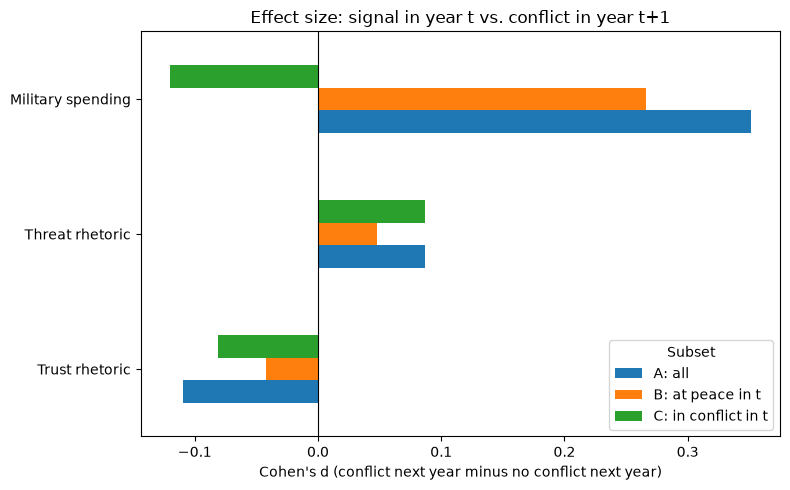

In [26]:
variable_labels = {
    "trust_score": "Trust rhetoric",
    "threat_score": "Threat rhetoric",
    "milex_pct_gdp": "Military spending",
}
effect_table = results.pivot(index="variable", columns="subset", values="cohens_d")
effect_table = effect_table.loc[variables].rename(index=variable_labels)

fig, ax = plt.subplots(figsize=(8, 5))
effect_table.plot.barh(ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (conflict next year minus no conflict next year)")
ax.set_ylabel("")
ax.set_title("Effect size: signal in year t vs. conflict in year t+1")
ax.legend(title="Subset")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "effect_sizes.pdf"), bbox_inches="tight")
plt.show()

### Is speech length a confound?

Speeches are longer in the earlier years of our window, especially in the 1990s. If longer speeches scored systematically higher or lower, length rather than content could drive the rhetoric scores. We therefore check the correlation between speech length (in tokens) and both scores.

               speech_length  trust_score  threat_score
speech_length       1.000000     0.010517     -0.017800
trust_score         0.010517     1.000000     -0.091499
threat_score       -0.017800    -0.091499      1.000000


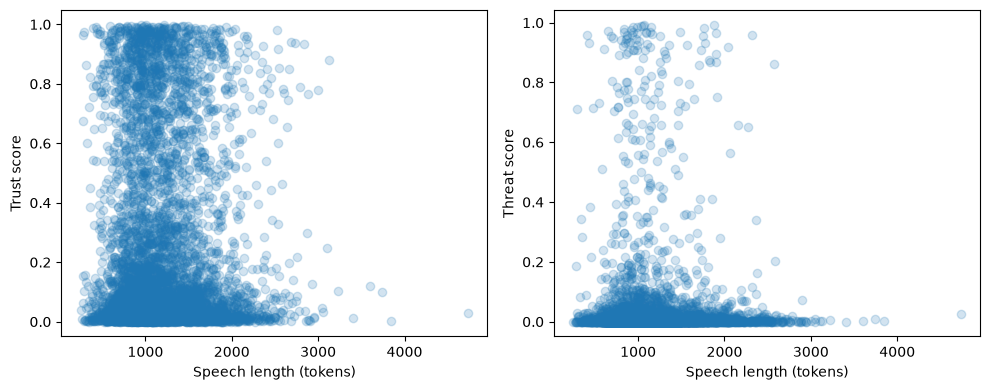

In [27]:
correlation = merged[["speech_length", "trust_score", "threat_score"]].corr()
print(correlation)

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(merged["speech_length"], merged["trust_score"], alpha=0.2)
axes[0].set_xlabel("Speech length (tokens)")
axes[0].set_ylabel("Trust score")

axes[1].scatter(merged["speech_length"], merged["threat_score"], alpha=0.2)
axes[1].set_xlabel("Speech length (tokens)")
axes[1].set_ylabel("Threat score")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "length_vs_scores.pdf"), bbox_inches="tight")
plt.show()

## Trends over time

Average trust/cooperation and military-threat scores per year across the 1990 to 2025 window.

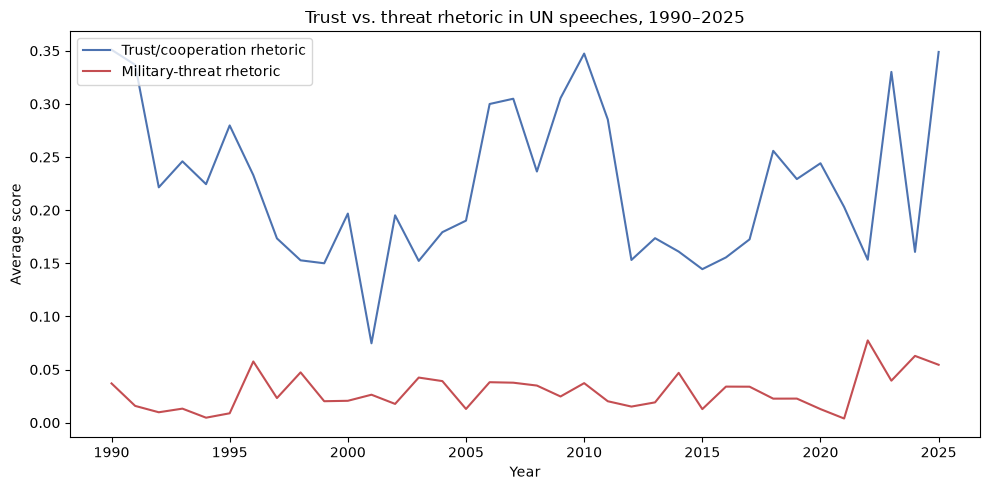

In [28]:
trend = merged.groupby("Year")[["trust_score", "threat_score"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend.index, trend["trust_score"], label="Trust/cooperation rhetoric", color="#4C72B0")
ax.plot(trend.index, trend["threat_score"], label="Military-threat rhetoric", color="#C44E52")
ax.set_xlabel("Year")
ax.set_ylabel("Average score")
ax.legend(loc="upper left")
ax.set_title("Trust vs. threat rhetoric in UN speeches, 1990–2025")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "rhetoric_trend.pdf"), bbox_inches="tight")
plt.show()

Average military spending per year, split by whether the country is in conflict the following year. This shows whether the spending gap is stable over time. 2025 is not shown because it has no outcome.

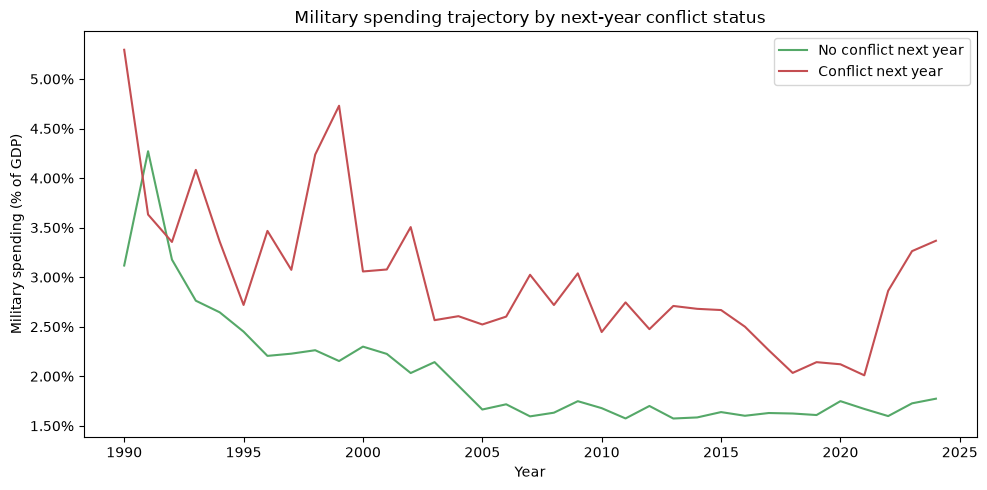

In [29]:
spend_trend = with_outcome.groupby(["Year", "conflict_active_next_year"])["milex_pct_gdp"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
spend_trend[0.0].plot(ax=ax, label="No conflict next year", color="#55A868")
spend_trend[1.0].plot(ax=ax, label="Conflict next year", color="#C44E52")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_ylabel("Military spending (% of GDP)")
ax.legend()
ax.set_title("Military spending trajectory by next-year conflict status")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "spending_trend.pdf"), bbox_inches="tight")
plt.show()

## Summary of exploratory findings

Across all speeches (A), speeches followed by conflict next year have slightly lower trust scores (0.190 vs 0.224; t-test p = 0.001, d = -0.11), slightly higher threat scores (0.037 vs 0.027; p = 0.010, d = 0.09) and higher military spending (2.98% vs 1.99% of GDP; p < 0.0001, d = 0.35). Most of these speeches (901 of 1,056) come from countries already in conflict in year t, so panel A partly reflects that conflicts tend to persist. Among countries at peace (B, new conflict onset) only spending differs (2.44% vs 1.93%, p = 0.002, d = 0.27), and the rhetoric differences are small and not significant. Among countries in conflict (C) no rhetoric difference is significant, and for spending the two tests disagree (t-test p = 0.20, Mann-Whitney p = 0.037, d = -0.12), so we treat that result as uncertain. All rhetoric effects are small, and the scores only describe the opening of each speech (the first 512 of about 2,900 tokens), so they should be read with caution.